In [95]:
import os
import sys
import numpy as np
import pandas as pd
from scipy import stats
import shap

In [ ]:
X = pd.read_pickle('../../data/shap/nhanesi_x_values.pkl')
num_patients = 500
X_shapley = X.iloc[:num_patients, :].reset_index(drop=True)
shap_values = np.load("../../data/shap/nhanesi_shap_values.npy")
shap_interaction_values = np.load("../../data/shap/nhanesi_shap_interaction_values.npy")

In [97]:
variable_A_name = "age"
variable_A_index = X.columns.get_loc(variable_A_name)
variable_B_name = "sex_isFemale"
variable_B_index = X.columns.get_loc(variable_B_name)

In [98]:
from cgt_perezsechi.exploration.sampling import sample_size_kruskal_wallis

sample_size = sample_size_kruskal_wallis(X_shapley, shap_values, variable_A_name, acceleration=1)

In [99]:
from cgt_perezsechi.manipulation.coding import code_interval

X_coded = code_interval(X_shapley, variable_A_name, sample_size)
X_coded.loc[X_coded[f'{variable_A_name}_interval'] == "[74,74]", f'{variable_A_name}_interval'] = "[68,74]"
X_coded[f'{variable_A_name}_interval'] = X_coded[f'{variable_A_name}_interval'].str.replace(']', ')')
X_coded.loc[X_coded[f'{variable_A_name}_interval'] == "[69,74)", f'{variable_A_name}_interval'] = "[68,74]"
X_coded.loc[X_coded[f'{variable_A_name}_interval'] == "[33,41)", f'{variable_A_name}_interval'] = "[32,41)"
df_A = pd.DataFrame({
    variable_A_name: X_coded[f'{variable_A_name}_interval'],
    'shap': shap_values[:, X.columns.get_loc(variable_A_name)]
})

In [100]:
df_A.groupby(['age']).count()

,shap
age,
"[25,32)",85
"[32,41)",85
"[41,48)",85
"[48,58)",85
"[58,68)",85
"[68,74]",75


In [101]:
df_B = pd.DataFrame({
    variable_B_name: X_shapley[variable_B_name],
    'shap': shap_values[:, X.columns.get_loc(variable_B_name)]
})

In [102]:
variable_B_index = X_shapley.columns.get_loc(variable_B_name)
shap_values_B = shap_values[:, variable_B_index]
variable_values = X_shapley[variable_B_name].values

## Construcción de matrices de adyacencia

In [103]:
shap_interaction_values_A_B = shap_interaction_values[:, variable_A_index, variable_B_index]
df_interaction = pd.DataFrame({
    variable_A_name: X_coded[f'{variable_A_name}_interval'],
    variable_B_name: X_coded[variable_B_name],
    'shap_interaction': shap_interaction_values_A_B
})
df_interaction_grouped = df_interaction.groupby([variable_A_name, variable_B_name]).agg(["mean"]).reset_index()
df_interaction_grouped.columns = [variable_A_name, variable_B_name, 'shap_interaction']
df_interaction_grouped

,age,sex_isFemale,shap_interaction
0,"[25,32)",False,-0.047614
1,"[25,32)",True,0.044601
2,"[32,41)",False,-0.044319
3,"[32,41)",True,0.040316
4,"[41,48)",False,-0.020452
5,"[41,48)",True,0.020656
6,"[48,58)",False,0.023100
7,"[48,58)",True,-0.015277
8,"[58,68)",False,0.054892
9,"[58,68)",True,-0.046696


In [104]:
unique_A_values = df_interaction_grouped[variable_A_name].unique()
unique_B_values = df_interaction_grouped[variable_B_name].unique()
variable_A_column_names = [f"{variable_A_name}_{value}" for value in unique_A_values]
variable_B_column_names = [f"{variable_B_name}_{value}" for value in unique_B_values]
column_names = variable_A_column_names + variable_B_column_names
r = pd.DataFrame(
    columns=column_names,
)

for A_value in unique_A_values:
    for B_value in unique_B_values:
        index_A = f"{variable_A_name}_{A_value}" 
        index_B = f"{variable_B_name}_{B_value}" 
        shap_interaction = df_interaction_grouped[
            (df_interaction_grouped[variable_A_name] == A_value) &
            (df_interaction_grouped[variable_B_name] == B_value)
        ]['shap_interaction'].values[0]
        r.loc[index_A, index_B] = shap_interaction
        r.loc[index_B, index_A] = shap_interaction

r.replace(np.nan, 0, inplace=True)
r_1 = r

/tmp/ipykernel_36207/2317974099.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r.replace(np.nan, 0, inplace=True)


In [105]:
r_1

,"age_[25,32)","age_[32,41)","age_[41,48)","age_[48,58)","age_[58,68)","age_[68,74]",sex_isFemale_False,sex_isFemale_True
"age_[25,32)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.047614,0.044601
sex_isFemale_False,-0.047614,-0.044319,-0.020452,0.023100,0.054892,0.033050,0.000000,0.000000
sex_isFemale_True,0.044601,0.040316,0.020656,-0.015277,-0.046696,-0.026826,0.000000,0.000000
"age_[32,41)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.044319,0.040316
"age_[41,48)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.020452,0.020656
"age_[48,58)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023100,-0.015277
"age_[58,68)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.054892,-0.046696
"age_[68,74]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.033050,-0.026826


## Representación en grafo de la interacción entre valores de las variables "age" y "sex_isFemale"

In [106]:
df_A_stats = df_A.groupby(variable_A_name).agg(['mean']).reset_index()
df_A_stats.columns = [variable_A_name, 'shap']
df_B_stats = df_B.groupby(variable_B_name).agg(['mean']).reset_index()
df_B_stats.columns = [variable_B_name, 'shap']

In [107]:
df_A_stats

,age,shap
0,"[25,32)",-1.574522
1,"[32,41)",-1.381704
2,"[41,48)",-0.916471
3,"[48,58)",-0.305183
4,"[58,68)",0.798914
5,"[68,74]",1.311658


In [108]:
psi_1 = pd.DataFrame(
    columns=['value'],
)

for index, row in df_A_stats.iterrows():
    psi_1.loc[f'{variable_A_name}_{row[variable_A_name]}', 'value'] = row['shap']
for index, row in df_B_stats.iterrows():
    psi_1.loc[f'{variable_B_name}_{row[variable_B_name]}', 'value'] = row['shap']

psi_1.index.name = None
psi_1

,value
"age_[25,32)",-1.574522
"age_[32,41)",-1.381704
"age_[41,48)",-0.916471
"age_[48,58)",-0.305183
"age_[58,68)",0.798914
"age_[68,74]",1.311658
sex_isFemale_False,0.207952
sex_isFemale_True,-0.190283


In [109]:
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r

psi_2 = normalize_psi(psi_1)
r_2 = normalize_r(r_1)

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  max_edge_width = r.applymap(lambda x: abs(x)).max().max()
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(lambda x: x / max_edge_width)


In [110]:
import regex as re
# Create new column names with TeX expressions
r_2_cols = r_2.columns.str.replace('age_', r'Age \in ').str.replace(r'^|$', '$', regex=True)
r_2_cols = r_2_cols.str.replace('sex_isFemale_False', 'Sex = Male') 
r_2_cols = r_2_cols.str.replace('sex_isFemale_True', 'Sex = Female') 
r_2.columns = r_2_cols

# Update index as well
r_2.index = r_2.index.str.replace('age_', r'Age \in ').str.replace(r'^|$', '$', regex=True)
r_2.index = r_2.index.str.replace('sex_isFemale_False', 'Sex = Male')
r_2.index = r_2.index.str.replace('sex_isFemale_True', 'Sex = Female')

# Update psi_2 index
psi_2.index = psi_2.index.str.replace('age_', r'Age \in ').str.replace(r'^|$', '$', regex=True)
psi_2.index = psi_2.index.str.replace('sex_isFemale_False', 'Sex = Male')
psi_2.index = psi_2.index.str.replace('sex_isFemale_True', 'Sex = Female')

In [111]:
r_2

,"$Age \in [25,32)$","$Age \in [32,41)$","$Age \in [41,48)$","$Age \in [48,58)$","$Age \in [58,68)$","$Age \in [68,74]$",$Sex = Male$,$Sex = Female$
"$Age \in [25,32)$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.867421,0.812525
$Sex = Male$,-0.867421,-0.807393,-0.372583,0.420831,1.000000,0.602094,0.000000,0.000000
$Sex = Female$,0.812525,0.734471,0.376303,-0.278303,-0.850695,-0.488711,0.000000,0.000000
"$Age \in [32,41)$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.807393,0.734471
"$Age \in [41,48)$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.372583,0.376303
"$Age \in [48,58)$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.420831,-0.278303
"$Age \in [58,68)$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-0.850695
"$Age \in [68,74]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.602094,-0.488711


In [112]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(1.0)[:3]
negative_color = shap_cmap(0.0)[:3] 

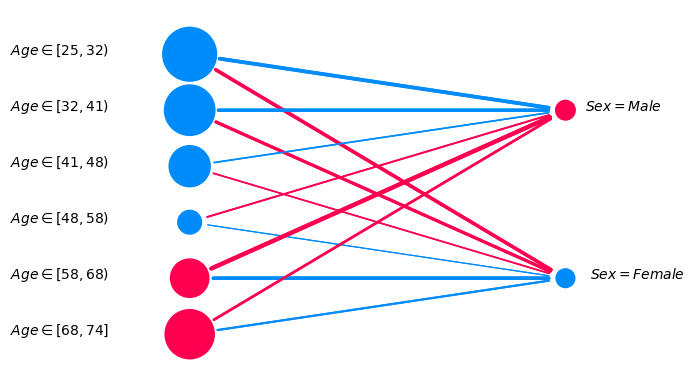

In [ ]:
from cgt_perezsechi.visualization.graph import draw

positive_alpha = 0
negative_alpha = 0
positive_beta = 0
negative_beta = 0
draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=positive_alpha,
    negative_alpha=negative_alpha,
    positive_beta=positive_beta,
    negative_beta=negative_beta,
    positive_color=positive_color,
    negative_color=negative_color,
    layout="shell",
    node_label_size_limit=5000,
    node_pos={
        r'$Sex = Male$': (350, 600),
        r'$Sex = Female$': (350, 300),
        r'$Age \in [25,32)$': (90, 700),
        r'$Age \in [32,41)$': (90, 600),
        r'$Age \in [41,48)$': (90, 500),
        r'$Age \in [48,58)$': (90, 400),
        r'$Age \in [58,68)$': (90, 300),
        r'$Age \in [68,74]$': (90, 200),
    },
    label_pos={
        r'$Sex = Male$': (390, 600),
        r'$Sex = Female$': (400, 300),
        r'$Age \in [25,32)$': (0, 700),
        r'$Age \in [32,41)$': (0, 600),
        r'$Age \in [41,48)$': (0, 500),
        r'$Age \in [48,58)$': (0, 400),
        r'$Age \in [58,68)$': (0, 300),
        r'$Age \in [68,74]$': (0, 200),
    },
    plot_margin=0.1,
    label_color="#000000",
)